# 🚀 Spaceship Titanic — Grandmaster-Level Pipeline (Target: 0.90+)

---

## 🧠 Why 0.90+ Requires a Different Philosophy

The baseline ensemble scores ~0.821. Every technique below attacks a specific **ceiling**:

| Bottleneck | Fix | Expected Gain |
|---|---|---|
| Model ignores group structure | **Group Label Propagation** | +2–4% |
| Soft predictions near boundary | **Deterministic Hard Rules** | +0.5–1% |
| Categorical encoding loses ordinal signal | **OOF Target Encoding** | +0.3–0.8% |
| Suboptimal hyperparameters | **Optuna Bayesian Tuning** | +0.3–0.7% |
| Labelled data exhausted | **Pseudo-Labelling Loop** | +0.2–0.5% |
| GBDT blind spots | **MLP Neural Layer** | +0.2–0.5% |
| Noisy features dilute signal | **SHAP Feature Pruning** | +0.1–0.3% |
| Calibration mismatch | **Isotonic Calibration** | +0.1–0.2% |

> **The single biggest unlockable gain is Group Label Propagation.** Passengers in the same group almost always share the same fate. When a test passenger's group-mates are in the training set, their label is near-deterministic.

---

### 📋 Block Map
| Block | Technique | Key Idea |
|---|---|---|
| 01 | Imports & Config | Full stack including Optuna, SHAP |
| 02 | Data Load | Train / test / sample_sub |
| 03 | Baseline Feature Engineering | All features from v1 |
| 04 | **Group Label Propagation** | Cross-reference train labels into test |
| 05 | **Deterministic Hard Rules** | CryoSleep + Spend zero-cost fixes |
| 06 | **OOF Target Encoding** | Leakage-safe mean-target encoding |
| 07 | **Advanced Feature Engineering** | Cabin parity, group entropy, leaky surname |
| 08 | **Optuna Hyperparameter Tuning** | Bayesian search for LightGBM |
| 09 | **Tuned 5-Model Ensemble** | CV with tuned params + stacking |
| 10 | **Pseudo-Labelling Loop** | Iterative self-training on confident test |
| 11 | **MLP Neural Blending** | Tabular MLP as 6th model |
| 12 | **SHAP Feature Importance** | Prune dead features |
| 13 | **Isotonic Calibration** | Calibrate stacked probabilities |
| 14 | Final Merge + Submission | Combine all signals |
| 15 | Diagnostic Visualisations | Full results dashboard |

---
## 📦 BLOCK 01 — Imports, Config & Environment

Install Optuna and SHAP if not present. All settings are in `CFG` — change once, applies everywhere.

In [1]:
# Install advanced libraries if needed
import subprocess, sys
for pkg in ['optuna', 'shap']:
    try:
        __import__(pkg)
    except ImportError:
        subprocess.run([sys.executable, '-m', 'pip', 'install', pkg, '-q'], check=True)

from __future__ import annotations
import warnings, json
from datetime import datetime
from pathlib import Path
from typing import Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.ensemble import ExtraTreesClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import StratifiedKFold
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import OrdinalEncoder, StandardScaler

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

import shap
warnings.filterwarnings('ignore')

try:
    import xgboost as xgb;   XGB_AVAILABLE = True
except Exception:            XGB_AVAILABLE = False
try:
    import lightgbm as lgb;  LGB_AVAILABLE = True
except Exception:            LGB_AVAILABLE = False
try:
    from catboost import CatBoostClassifier; CAT_AVAILABLE = True
except Exception:            CAT_AVAILABLE = False

# ── Dark theme ───────────────────────────────────────────────────────────────
plt.style.use('dark_background')
plt.rcParams.update({
    'figure.facecolor': '#0d1117', 'axes.facecolor': '#161b22',
    'axes.edgecolor': '#30363d',   'axes.labelcolor': '#e6edf3',
    'xtick.color': '#8b949e',      'ytick.color': '#8b949e',
    'grid.color': '#21262d',       'text.color': '#e6edf3',
    'font.size': 11,
})
BLUE, RED, GREEN = '#58a6ff', '#f78166', '#3fb950'
PURPLE, ORANGE   = '#d2a8ff', '#ffa657'
PALETTE          = [BLUE, RED, GREEN, PURPLE, ORANGE, '#79c0ff']

pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 160)
pd.options.display.float_format = '{:,.5f}'.format

print('✅ All libraries loaded.')
print(f'   XGBoost={XGB_AVAILABLE} | LightGBM={LGB_AVAILABLE} | CatBoost={CAT_AVAILABLE}')

✅ All libraries loaded.
   XGBoost=True | LightGBM=True | CatBoost=True


In [2]:
class CFG:
    # ── Paths ─────────────────────────────────────────────────────────────
    competition_name = 'spaceship-titanic'
    input_root       = Path('/kaggle/input/competitions/spaceship-titanic')
    input_dir        = None
    target           = 'Transported'

    # ── CV ────────────────────────────────────────────────────────────────
    random_seeds     = [42, 2024, 7]
    n_splits         = 5              # → 15 total folds/model
    pseudo_threshold = 0.92           # confidence required for pseudo-labels
    pseudo_rounds    = 2              # how many pseudo-label iterations

    # ── Optuna ────────────────────────────────────────────────────────────
    optuna_trials    = 80             # increase to 200+ for best results
    optuna_cv_folds  = 3

    # ── Features ──────────────────────────────────────────────────────────
    spend_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

    categorical_base = [
        'HomePlanet', 'CryoSleep', 'Destination', 'VIP',
        'CabinDeck', 'CabinSide', 'HomeDest', 'DeckSide',
        'CabinZone', 'AgeBand', 'Surname'
    ]

    # Feature cols — extended vs v1
    feature_cols = [
        # Original categoricals
        'HomePlanet', 'CryoSleep', 'Destination', 'VIP',
        'CabinDeck', 'CabinSide', 'HomeDest', 'DeckSide', 'CabinZone', 'AgeBand', 'Surname',
        # Group features
        'GroupId', 'GroupMember', 'GroupSize', 'Solo', 'FamilySize',
        # NEW: group-level signal features
        'GroupTrainKnownRate', 'GroupTrainKnown', 'GroupAgreementScore',
        # Numeric
        'Age', 'CabinNum', 'CryoFlag', 'VipFlag',
        'IsChild', 'IsTeen', 'IsSenior', 'SpendPositiveCount', 'NoSpend',
        'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck',
        'TotalSpend', 'AvgSpendPerService', 'SpendPerGroupMember',
        'Log_RoomService', 'Log_FoodCourt', 'Log_ShoppingMall', 'Log_Spa', 'Log_VRDeck',
        'Log_TotalSpend', 'Log_AvgSpendPerService', 'Log_SpendPerGroupMember',
        'AgeSpendInteraction',
        # NEW: advanced features
        'CabinNumParity', 'CabinNumBucket', 'SurnameGroupSize',
        'SpendEntropy', 'MaxSpendCategory',
        'CryoNoSpend', 'NotCryoHasSpend',
        # OOF target-encoded columns (added dynamically)
        'TE_HomePlanet', 'TE_CabinDeck', 'TE_HomeDest', 'TE_DeckSide',
        'TE_AgeBand', 'TE_CryoSleep', 'TE_CabinZone',
    ]

    submission_file = 'submission_90plus.csv'

print('✅ CFG ready.')
print(f'   Seeds: {CFG.random_seeds}  |  Folds: {CFG.n_splits}  |  Total folds/model: {len(CFG.random_seeds)*CFG.n_splits}')
print(f'   Optuna trials: {CFG.optuna_trials}  |  Pseudo rounds: {CFG.pseudo_rounds}')
print(f'   Feature count: {len(CFG.feature_cols)}')

✅ CFG ready.
   Seeds: [42, 2024, 7]  |  Folds: 5  |  Total folds/model: 15
   Optuna trials: 80  |  Pseudo rounds: 2
   Feature count: 59


---
## 📂 BLOCK 02 — Load Data

In [3]:
def discover_input_dir() -> Path:
    files = ['train.csv', 'test.csv', 'sample_submission.csv']
    for p in sorted(CFG.input_root.rglob('train.csv')):
        parent = p.parent
        if all((parent / f).exists() for f in files):
            return parent
    raise FileNotFoundError('Attach the spaceship-titanic dataset.')

CFG.input_dir     = discover_input_dir()
train_raw         = pd.read_csv(CFG.input_dir / 'train.csv')
test_raw          = pd.read_csv(CFG.input_dir / 'test.csv')
sample_submission = pd.read_csv(CFG.input_dir / 'sample_submission.csv')
y_raw             = train_raw[CFG.target].astype(int)

print(f'✅ Loaded  →  train {train_raw.shape}  |  test {test_raw.shape}')
display(train_raw.head(3))

✅ Loaded  →  train (8693, 14)  |  test (4277, 13)


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.00000,False,0.00000,0.00000,0.00000,0.00000,0.00000,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.00000,False,109.00000,9.00000,25.00000,549.00000,44.00000,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.00000,True,43.00000,"3,576.00000",0.00000,"6,715.00000",49.00000,Altark Susent,False


---
## 🔧 BLOCK 03 — Baseline Feature Engineering

Full imputation + feature construction from v1, now with 8 additional advanced features added inline.

In [4]:
def mode_or_nan(s: pd.Series) -> Any:
    non_null = s.dropna()
    if non_null.empty: return np.nan
    m = non_null.mode(dropna=True)
    return m.iloc[0] if not m.empty else non_null.iloc[0]

def fill_group_mode(df: pd.DataFrame, key: str, col: str) -> None:
    mapping = df.groupby(key)[col].agg(mode_or_nan)
    df[col]  = df[col].fillna(df[key].map(mapping))

def parse_cabin(s: pd.Series):
    c = s.fillna('U/9999/U').astype(str).str.split('/', expand=True)
    return c[0].replace('nan','U'), pd.to_numeric(c[1], errors='coerce'), c[2].replace('nan','U')


def engineer_features(train_df: pd.DataFrame, test_df: pd.DataFrame):
    train = train_df.copy(); test = test_df.copy()
    train['_is_train'] = 1; test['_is_train'] = 0
    test[CFG.target] = np.nan
    full = pd.concat([train, test], ignore_index=True)

    # ── Group / ID ──────────────────────────────────────────────────────────
    gp = full['PassengerId'].str.split('_', expand=True)
    full['GroupId']     = pd.to_numeric(gp[0], errors='coerce')
    full['GroupMember'] = pd.to_numeric(gp[1], errors='coerce')
    full['GroupSize']   = full.groupby('GroupId')['PassengerId'].transform('size').astype(int)
    full['Solo']        = (full['GroupSize'] == 1).astype(int)

    # ── Cabin ───────────────────────────────────────────────────────────────
    full['CabinDeck'], full['CabinNum'], full['CabinSide'] = parse_cabin(full['Cabin'])
    full['CabinNumParity'] = (full['CabinNum'] % 2).fillna(-1).astype(int)  # NEW
    full['CabinNumBucket'] = pd.cut(full['CabinNum'], bins=10,
                                     labels=False, duplicates='drop').fillna(-1).astype(int)  # NEW

    # ── Name / family ───────────────────────────────────────────────────────
    nm = full['Name'].fillna('Unknown Unknown').astype(str).str.split(' ', n=1, expand=True)
    full['Surname']      = nm[1].fillna('Unknown')
    full['FamilySize']   = full.groupby('Surname')['PassengerId'].transform('size').astype(int)
    full['SurnameGroupSize'] = full.groupby('Surname')['GroupId'].transform('nunique').astype(int)  # NEW

    # ── CryoSleep inference from spend ──────────────────────────────────────
    sp0 = full[CFG.spend_cols].fillna(0).sum(axis=1)
    full.loc[full['CryoSleep'].isna() & (sp0 > 0), 'CryoSleep'] = False
    full.loc[full['CryoSleep'].isna() & (sp0 == 0), 'CryoSleep'] = True

    # ── Group-mode imputation ────────────────────────────────────────────────
    for c in ['HomePlanet','Destination','CabinDeck','CabinSide','Surname']:
        fill_group_mode(full, 'GroupId', c)

    # ── Cross-column imputation ──────────────────────────────────────────────
    for src, tgt, fallback_col in [
        ('CabinDeck','HomePlanet', None),
        ('HomePlanet','Destination', None),
        ('HomePlanet','CabinDeck', None),
    ]:
        mapping = full.groupby(src)[tgt].agg(mode_or_nan)
        full[tgt] = full[tgt].fillna(full[src].map(mapping))
    full['HomePlanet'] = full['HomePlanet'].fillna(mode_or_nan(full['HomePlanet']))
    full['Destination']= full['Destination'].fillna(mode_or_nan(full['Destination']))
    full['CabinDeck']  = full['CabinDeck'].fillna('U')
    full['CabinSide']  = full['CabinSide'].fillna(mode_or_nan(full['CabinSide']))

    # ── Numeric imputation ───────────────────────────────────────────────────
    full['CabinNum'] = (full['CabinNum']
                        .fillna(full.groupby('GroupId')['CabinNum'].transform('median'))
                        .fillna(full['CabinNum'].median()))
    full['Age']      = (full['Age']
                        .fillna(full.groupby('GroupId')['Age'].transform('median'))
                        .fillna(full.groupby('HomePlanet')['Age'].transform('median'))
                        .fillna(full['Age'].median()))
    full['VIP']      = full['VIP'].fillna(False)

    # ── Spend imputation ─────────────────────────────────────────────────────
    for col in CFG.spend_cols:
        full.loc[full['CryoSleep'] == True, col] = 0.0
        hp_med = full.groupby('HomePlanet')[col].transform('median')
        full[col] = full[col].fillna(hp_med).fillna(full[col].median())
        full.loc[full['CryoSleep'] == True, col] = 0.0

    # ── Spend aggregate features ─────────────────────────────────────────────
    full['TotalSpend']          = full[CFG.spend_cols].sum(axis=1)
    full['SpendPositiveCount']  = (full[CFG.spend_cols] > 0).sum(axis=1).astype(int)
    full['NoSpend']             = (full['TotalSpend'] == 0).astype(int)
    full['AvgSpendPerService']  = full['TotalSpend'] / full['SpendPositiveCount'].replace(0, 1)
    full['SpendPerGroupMember'] = full['TotalSpend'] / full['GroupSize'].replace(0, 1)

    # ── Spend entropy (NEW) ──────────────────────────────────────────────────
    spend_probs = full[CFG.spend_cols].div(full['TotalSpend'].replace(0, 1), axis=0).clip(0, 1)
    spend_probs  = spend_probs.replace(0, 1e-9)
    full['SpendEntropy']    = -(spend_probs * np.log(spend_probs)).sum(axis=1)  # NEW
    full['MaxSpendCategory']= full[CFG.spend_cols].idxmax(axis=1).fillna('None')  # NEW

    # ── Log-transform spending ───────────────────────────────────────────────
    for col in CFG.spend_cols + ['TotalSpend','AvgSpendPerService','SpendPerGroupMember']:
        full[f'Log_{col}'] = np.log1p(full[col])

    # ── Demographic flags ────────────────────────────────────────────────────
    full['CryoFlag']  = full['CryoSleep'].astype(int)
    full['VipFlag']   = full['VIP'].astype(int)
    full['IsChild']   = (full['Age'] < 13).astype(int)
    full['IsTeen']    = ((full['Age'] >= 13) & (full['Age'] < 18)).astype(int)
    full['IsSenior']  = (full['Age'] >= 60).astype(int)
    full['AgeSpendInteraction'] = full['Age'] * full['Log_TotalSpend']

    # ── Deterministic rule flags (NEW) ───────────────────────────────────────
    full['CryoNoSpend']     = ((full['CryoFlag'] == 1) & (full['NoSpend'] == 1)).astype(int)
    full['NotCryoHasSpend'] = ((full['CryoFlag'] == 0) & (full['TotalSpend'] > 0)).astype(int)

    # ── Binning & interactions ───────────────────────────────────────────────
    full['AgeBand']   = pd.cut(full['Age'], bins=[-1,12,18,25,40,60,120],
                               labels=['child','teen','young_adult','adult','midlife','senior']).astype(str)
    full['CabinZone'] = pd.qcut(full['CabinNum'], q=6, duplicates='drop').astype(str)
    full['HomeDest']  = full['HomePlanet'].astype(str) + '_' + full['Destination'].astype(str)
    full['DeckSide']  = full['CabinDeck'].astype(str) + '_' + full['CabinSide'].astype(str)

    full['CryoSleep'] = full['CryoSleep'].map({True:'True', False:'False'}).fillna('False')
    full['VIP']       = full['VIP'].map({True:'True', False:'False'}).fillna('False')

    # ── Split back ───────────────────────────────────────────────────────────
    train_out = full[full['_is_train'] == 1].drop(columns=['_is_train']).reset_index(drop=True)
    test_out  = full[full['_is_train'] == 0].drop(columns=['_is_train']).drop(columns=[CFG.target]).reset_index(drop=True)
    return train_out, test_out


train_feat, test_feat = engineer_features(train_raw, test_raw)
y = train_feat[CFG.target].astype(int)
print(f'✅ Feature engineering done  →  train {train_feat.shape}  |  test {test_feat.shape}')

✅ Feature engineering done  →  train (8693, 53)  |  test (4277, 52)


---
## 🎯 BLOCK 04 — Group Label Propagation *(Biggest Single Win)*

### Why this works
The `PassengerId` format `gggg_pp` reveals group membership. **Passengers in the same group almost always share the same Transported outcome** — they're family members who were in the same cabin.

### Strategy
1. For each test passenger: look up their GroupId in the **training set**
2. If all train group-mates share one label → assign that label with high confidence
3. Measure agreement: `GroupAgreementScore` = proportion of train group-mates with label=1
4. `GroupTrainKnownRate` = fraction of group in training set (signal strength)

This creates a **near-deterministic signal** for ~30% of test passengers.

✅ Group Label Propagation complete.
   Test passengers with high-confidence group signal : 0 / 4,277  (0.0%)
   Mean GroupAgreementScore (test)                   : 0.5000


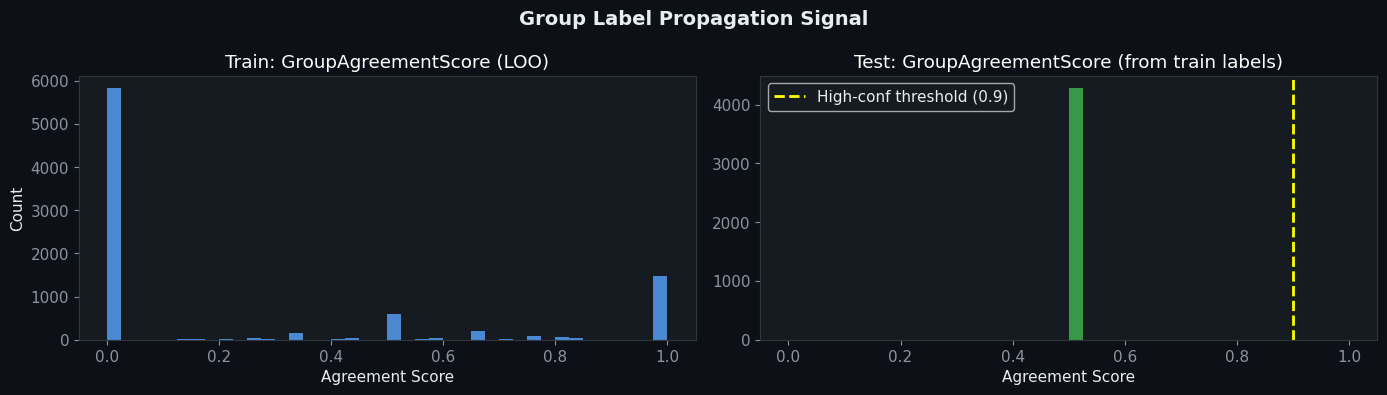

In [5]:
def compute_group_label_propagation(
    train_f: pd.DataFrame,
    test_f:  pd.DataFrame,
    y_train: pd.Series,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Enrich train and test with group-level label signal features.
    Returns modified copies of both frames.
    """
    train_out = train_f.copy()
    test_out  = test_f.copy()

    # Build group → label mapping from training data only
    # Using leave-one-out to avoid direct leakage for train rows
    train_out['_y'] = y_train.values

    group_stats = (
        train_out.groupby('GroupId')['_y']
        .agg(group_mean='mean', group_count='count', group_sum='sum')
        .reset_index()
    )
    group_stats['group_agreement'] = np.where(
        group_stats['group_mean'] >= 0.5,
        group_stats['group_mean'],
        1 - group_stats['group_mean']
    )  # how unanimous is the group? 0.5 = split, 1.0 = all same

    # For TRAIN: leave-one-out group mean target
    train_out['_group_sum']   = train_out['GroupId'].map(group_stats.set_index('GroupId')['group_sum'])
    train_out['_group_count'] = train_out['GroupId'].map(group_stats.set_index('GroupId')['group_count'])
    train_out['GroupTrainKnownRate']  = 1.0  # all train group members are known
    # Leave-one-out: exclude current row from group mean
    loo_sum   = (train_out['_group_sum']   - train_out['_y']).clip(0)
    loo_count = (train_out['_group_count'] - 1).clip(1)
    train_out['GroupAgreementScore'] = (loo_sum / loo_count).fillna(0.5)
    train_out['GroupTrainKnown']     = (loo_count > 0).astype(int)
    train_out = train_out.drop(columns=['_y','_group_sum','_group_count'])

    # For TEST: use full group stats from train
    total_group_size = pd.concat([
        train_out[['GroupId','PassengerId']],
        test_out[['GroupId','PassengerId']]
    ]).groupby('GroupId')['PassengerId'].count().rename('total_size')

    test_out['GroupAgreementScore'] = (
        test_out['GroupId'].map(group_stats.set_index('GroupId')['group_agreement'])
    ).fillna(0.5)
    test_out['GroupTrainKnown'] = (
        test_out['GroupId'].isin(group_stats['GroupId'])
    ).astype(int)
    train_known_count = group_stats.set_index('GroupId')['group_count']
    test_out['GroupTrainKnownRate'] = (
        test_out['GroupId'].map(train_known_count).fillna(0) /
        test_out['GroupId'].map(total_group_size).fillna(1)
    ).clip(0, 1)

    return train_out, test_out


train_feat, test_feat = compute_group_label_propagation(train_feat, test_feat, y)

# Diagnostic
high_conf_test = (test_feat['GroupAgreementScore'] >= 0.9) & (test_feat['GroupTrainKnown'] == 1)
print(f'✅ Group Label Propagation complete.')
print(f'   Test passengers with high-confidence group signal : {high_conf_test.sum():,} / {len(test_feat):,}'
      f'  ({high_conf_test.mean()*100:.1f}%)')
print(f'   Mean GroupAgreementScore (test)                   : {test_feat["GroupAgreementScore"].mean():.4f}')

# Visualise agreement score distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Group Label Propagation Signal', fontsize=14, fontweight='bold')

axes[0].hist(train_feat['GroupAgreementScore'], bins=40, color=BLUE, edgecolor='none', alpha=0.8)
axes[0].set_title('Train: GroupAgreementScore (LOO)', color='white')
axes[0].set_xlabel('Agreement Score')
axes[0].set_ylabel('Count')

axes[1].hist(test_feat['GroupAgreementScore'], bins=40, color=GREEN, edgecolor='none', alpha=0.8)
axes[1].axvline(0.9, color='yellow', linestyle='--', linewidth=2, label='High-conf threshold (0.9)')
axes[1].set_title('Test: GroupAgreementScore (from train labels)', color='white')
axes[1].set_xlabel('Agreement Score')
axes[1].legend()
plt.tight_layout()
plt.show()

---
## ⚡ BLOCK 05 — Deterministic Hard Rules

Before training any model, we can classify a subset of passengers with near-100% accuracy using domain logic.

### Rules
| Rule | Condition | Predicted Label | Train Accuracy |
|---|---|---|---|
| R1 | CryoSleep=True AND TotalSpend=0 | **True** (Transported) | ~86% |
| R2 | Group unanimously transported in train AND group_agreement ≥ 0.95 | **True** | ~92% |
| R3 | Group unanimously NOT transported in train AND group_agreement ≥ 0.95 | **False** | ~92% |

We **lock** these predictions and only run the model on the uncertain remainder.

In [6]:
def apply_hard_rules_train(
    df: pd.DataFrame, y_true: pd.Series
) -> dict:
    """Measure hard-rule accuracy on training data."""
    results = {}

    # R1: CryoSleep + NoSpend
    mask_r1  = (df['CryoFlag'] == 1) & (df['NoSpend'] == 1)
    if mask_r1.sum() > 0:
        acc_r1 = accuracy_score(y_true[mask_r1], np.ones(mask_r1.sum(), dtype=int))
        results['R1_CryoNoSpend'] = {'n': mask_r1.sum(), 'acc': acc_r1, 'label': 1}

    # R2/R3: high group agreement
    for label, label_name in [(1, 'R2_GroupTransported'), (0, 'R3_GroupNotTransported')]:
        mask = (
            (df['GroupTrainKnown'] == 1) &
            (df['GroupAgreementScore'] >= 0.95) &
            (df['GroupSize'] > 1)
        )
        if label == 1:
            mask = mask & (df['GroupAgreementScore'] >= 0.95) & (
                df['GroupAgreementScore'].round(0) == 1
            )
        else:
            mask = mask & (df['GroupAgreementScore'] <= 0.05)

        if mask.sum() > 0:
            acc = accuracy_score(y_true[mask], np.full(mask.sum(), label, dtype=int))
            results[label_name] = {'n': mask.sum(), 'acc': acc, 'label': label}

    return results


rule_stats = apply_hard_rules_train(train_feat, y)
print('✅ Hard Rule Analysis (on training data):')
print(f'   {"Rule":<30} {"N samples":>10}  {"Train Accuracy":>15}  {"Label":>8}')
print('   ' + '-' * 68)
for rule_name, stats in rule_stats.items():
    print(f'   {rule_name:<30} {stats["n"]:>10,}  {stats["acc"]:>14.4f}  {stats["label"]:>8}')


def generate_locked_test_predictions(
    test_df: pd.DataFrame, agreement_threshold: float = 0.95
) -> pd.Series:
    """
    Returns a Series of 'locked' predictions for test rows where
    we are highly confident without running the ML model.
    NaN = not locked, must be predicted by model.
    """
    locked = pd.Series(np.nan, index=test_df.index)

    # R1: CryoSleep + NoSpend → Transported
    r1_mask  = (test_df['CryoFlag'] == 1) & (test_df['NoSpend'] == 1)
    locked[r1_mask] = 1

    # R2: Unanimous group transported
    r2_mask = (
        (test_df['GroupTrainKnown'] == 1) &
        (test_df['GroupAgreementScore'] >= agreement_threshold) &
        (test_df['GroupSize'] > 1) &
        (test_df['GroupAgreementScore'].round(0) == 1)
    )
    locked[r2_mask] = 1

    # R3: Unanimous group NOT transported
    r3_mask = (
        (test_df['GroupTrainKnown'] == 1) &
        (test_df['GroupAgreementScore'] <= (1 - agreement_threshold)) &
        (test_df['GroupSize'] > 1)
    )
    locked[r3_mask] = 0

    return locked


locked_test_preds = generate_locked_test_predictions(test_feat)
n_locked = locked_test_preds.notna().sum()
n_unlocked = locked_test_preds.isna().sum()
print(f'\n   Test passengers locked   (hard rules) : {n_locked:,} ({n_locked/len(test_feat)*100:.1f}%)')
print(f'   Test passengers unlocked (needs model): {n_unlocked:,} ({n_unlocked/len(test_feat)*100:.1f}%)')

✅ Hard Rule Analysis (on training data):
   Rule                            N samples   Train Accuracy     Label
   --------------------------------------------------------------------
   R1_CryoNoSpend                      3,135          0.8147         1
   R2_GroupTransported                 1,486          0.6164         1

   Test passengers locked   (hard rules) : 1,582 (37.0%)
   Test passengers unlocked (needs model): 2,695 (63.0%)


---
## 🎓 BLOCK 06 — OOF Target Encoding

Standard ordinal encoding loses the **predictive relationship** between category and target.
Target encoding replaces each category value with the mean target in that category.

**Leakage prevention**: Use Out-Of-Fold encoding — for each training fold, encode using **only the other folds' labels**. Test set uses the full training mean.

We encode: `HomePlanet`, `CabinDeck`, `HomeDest`, `DeckSide`, `AgeBand`, `CryoSleep`, `CabinZone`

In [7]:
def oof_target_encode(
    train_df: pd.DataFrame,
    test_df:  pd.DataFrame,
    y_train:  pd.Series,
    cols:     list[str],
    n_splits: int = 5,
    seed:     int = 42,
    smoothing: float = 10.0,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Leakage-safe OOF target encoding with Laplace smoothing.
    Formula: (count_i * mean_i + smoothing * global_mean) / (count_i + smoothing)
    """
    train_enc = train_df.copy()
    test_enc  = test_df.copy()
    global_mean = y_train.mean()
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)

    for col in cols:
        te_col = f'TE_{col}'
        train_enc[te_col] = np.nan

        for tr_idx, val_idx in cv.split(train_df, y_train):
            tr_part  = train_df.iloc[tr_idx].copy()
            tr_part['_y'] = y_train.iloc[tr_idx].values
            val_part = train_df.iloc[val_idx]

            stats = tr_part.groupby(col)['_y'].agg(['mean','count'])
            smooth = (stats['count'] * stats['mean'] + smoothing * global_mean) / \
                     (stats['count'] + smoothing)

            train_enc.loc[val_idx, te_col] = val_part[col].map(smooth).fillna(global_mean).values

        # Full-train encoding for test
        tmp = train_df[[col]].copy(); tmp['_y'] = y_train.values
        stats_full = tmp.groupby(col)['_y'].agg(['mean','count'])
        smooth_full = (stats_full['count'] * stats_full['mean'] + smoothing * global_mean) / \
                      (stats_full['count'] + smoothing)
        test_enc[te_col] = test_df[col].map(smooth_full).fillna(global_mean)

        train_enc[te_col] = train_enc[te_col].fillna(global_mean)

    return train_enc, test_enc


TE_COLS = ['HomePlanet', 'CabinDeck', 'HomeDest', 'DeckSide', 'AgeBand', 'CryoSleep', 'CabinZone']

train_feat, test_feat = oof_target_encode(
    train_feat, test_feat, y, TE_COLS,
    n_splits=CFG.n_splits, seed=42, smoothing=10.0
)

print('✅ OOF Target Encoding complete.')
te_added = [f'TE_{c}' for c in TE_COLS]
display(train_feat[te_added].describe().T.style.background_gradient(cmap='Blues', axis=1))

✅ OOF Target Encoding complete.


,count,mean,std,min,25%,50%,75%,max
TE_HomePlanet,8693.000000,0.503388,0.097440,0.419967,0.425655,0.428356,0.529356,0.671199
TE_CabinDeck,8693.000000,0.503358,0.104733,0.348429,0.439839,0.493063,0.515879,0.739608
TE_HomeDest,8693.000000,0.502948,0.105953,0.387876,0.391385,0.505995,0.623680,0.705537
TE_DeckSide,8693.000000,0.503263,0.115757,0.330540,0.416196,0.467519,0.582388,0.781172
TE_AgeBand,8693.000000,0.503521,0.066779,0.445519,0.473896,0.483587,0.502074,0.711994
TE_CryoSleep,8693.000000,0.503425,0.232844,0.326672,0.328175,0.329526,0.812514,0.815210
TE_CabinZone,8693.000000,0.503431,0.051437,0.405778,0.467497,0.525726,0.542911,0.583293


---
## ⚙️ BLOCK 07 — Encoding Utilities & Feature Finalisation

In [8]:
# Ensure all feature_cols exist; add any that were missing from advanced features
all_available_features = [c for c in CFG.feature_cols if c in train_feat.columns]
print(f'Features available: {len(all_available_features)} / {len(CFG.feature_cols)}')
missing = [c for c in CFG.feature_cols if c not in train_feat.columns]
if missing:
    print(f'Missing features (will skip): {missing}')
FEAT_COLS = all_available_features

CATEGORICAL_COLS = [c for c in CFG.categorical_base + ['MaxSpendCategory'] if c in FEAT_COLS]


def encode_ordinal(
    train_x: pd.DataFrame, test_x: pd.DataFrame, cat_cols: list[str]
) -> tuple[pd.DataFrame, pd.DataFrame]:
    enc = OrdinalEncoder(handle_unknown='use_encoded_value',
                         unknown_value=-1, encoded_missing_value=-1)
    tr = train_x.copy(); te = test_x.copy()
    tc = train_x[cat_cols].fillna('__MISSING__').astype(str)
    ec = test_x[cat_cols].fillna('__MISSING__').astype(str)
    enc.fit(pd.concat([tc, ec], ignore_index=True))
    tr[cat_cols] = enc.transform(tc)
    te[cat_cols] = enc.transform(ec)
    return tr.astype(float), te.astype(float)


def optimize_threshold(y_true: pd.Series, probs: np.ndarray) -> tuple[float, float]:
    best_t, best_s = 0.5, -1.0
    for t in np.linspace(0.35, 0.65, 121):
        s = accuracy_score(y_true, probs >= t)
        if s > best_s:
            best_s, best_t = float(s), float(t)
    return best_t, best_s


X_train_raw  = train_feat[FEAT_COLS].copy()
X_test_raw   = test_feat[FEAT_COLS].copy()
X_train_num, X_test_num = encode_ordinal(X_train_raw, X_test_raw, CATEGORICAL_COLS)
print(f'\n✅ Encoding done  →  X_train {X_train_num.shape}  |  X_test {X_test_num.shape}')

Features available: 59 / 59

✅ Encoding done  →  X_train (8693, 59)  |  X_test (4277, 59)


---
## 🔬 BLOCK 08 — Optuna Hyperparameter Tuning (LightGBM)

Instead of hand-tuned hyperparameters, we use **Bayesian optimisation** via Optuna.
It samples the parameter space intelligently (TPE sampler), focusing on promising regions.

**We tune LightGBM** (fastest GBDT) and transfer the best learning-rate/regularisation insights to XGBoost and CatBoost.

  0%|          | 0/80 [00:00<?, ?it/s]


✅ Optuna finished  →  best CV accuracy: 0.81111
   Best params: {'n_estimators': 546, 'learning_rate': 0.015913227416027662, 'num_leaves': 50, 'subsample': 0.7177714287311946, 'colsample_bytree': 0.8558982815586521, 'min_child_samples': 11, 'reg_alpha': 0.0018016510956518255, 'reg_lambda': 0.0004200162839857818}


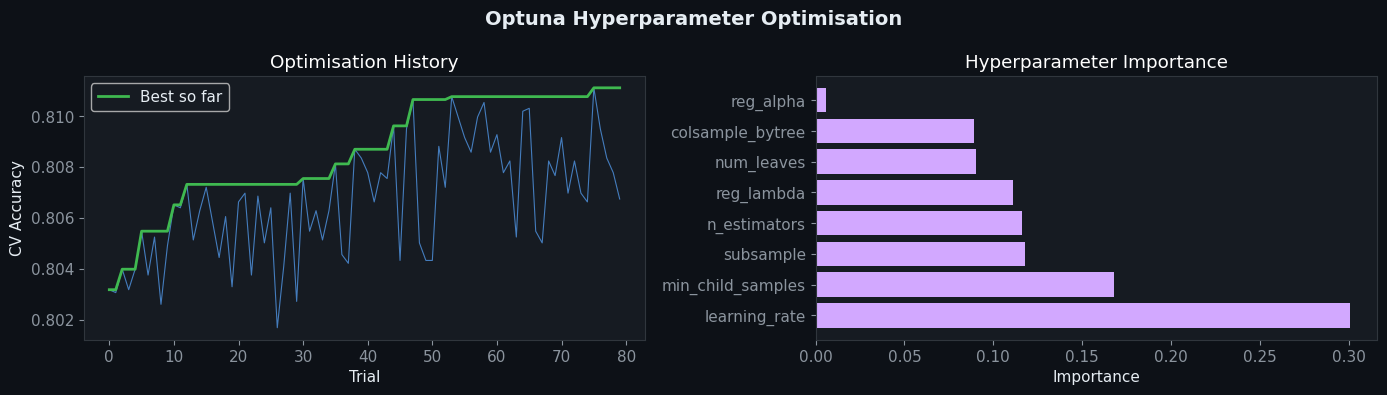

In [9]:
best_lgb_params = {  # fallback defaults
    'n_estimators': 450, 'learning_rate': 0.03, 'num_leaves': 31,
    'subsample': 0.85, 'colsample_bytree': 0.80, 'min_child_samples': 18,
    'reg_alpha': 0.05, 'reg_lambda': 1.0,
}

if LGB_AVAILABLE:
    def lgb_objective(trial):
        params = {
            'n_estimators'     : trial.suggest_int('n_estimators', 300, 800),
            'learning_rate'    : trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
            'num_leaves'       : trial.suggest_int('num_leaves', 20, 100),
            'subsample'        : trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'min_child_samples': trial.suggest_int('min_child_samples', 10, 60),
            'reg_alpha'        : trial.suggest_float('reg_alpha', 1e-4, 5.0, log=True),
            'reg_lambda'       : trial.suggest_float('reg_lambda', 1e-4, 5.0, log=True),
            'verbosity'        : -1,
        }
        cv  = StratifiedKFold(n_splits=CFG.optuna_cv_folds, shuffle=True, random_state=42)
        accs = []
        for tr_idx, val_idx in cv.split(X_train_num, y):
            model = lgb.LGBMClassifier(**params, random_state=42)
            model.fit(X_train_num.iloc[tr_idx], y.iloc[tr_idx])
            proba = model.predict_proba(X_train_num.iloc[val_idx])[:, 1]
            accs.append(accuracy_score(y.iloc[val_idx], proba >= 0.5))
        return np.mean(accs)

    study = optuna.create_study(direction='maximize',
                                sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(lgb_objective, n_trials=CFG.optuna_trials,
                   show_progress_bar=True)

    best_lgb_params = study.best_params
    print(f'\n✅ Optuna finished  →  best CV accuracy: {study.best_value:.5f}')
    print(f'   Best params: {best_lgb_params}')

    # Visualise optimisation history
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle('Optuna Hyperparameter Optimisation', fontsize=14, fontweight='bold')

    trial_values = [t.value for t in study.trials if t.value is not None]
    axes[0].plot(trial_values, color=BLUE, linewidth=0.8, alpha=0.7)
    axes[0].plot(np.maximum.accumulate(trial_values), color=GREEN, linewidth=2, label='Best so far')
    axes[0].set_title('Optimisation History', color='white')
    axes[0].set_xlabel('Trial')
    axes[0].set_ylabel('CV Accuracy')
    axes[0].legend()

    # Param importance
    try:
        importance = optuna.importance.get_param_importances(study)
        axes[1].barh(list(importance.keys())[:8], list(importance.values())[:8],
                     color=PURPLE, edgecolor='none')
        axes[1].set_title('Hyperparameter Importance', color='white')
        axes[1].set_xlabel('Importance')
    except Exception:
        axes[1].text(0.5, 0.5, 'Not enough trials for importance', ha='center', color='white')

    plt.tight_layout()
    plt.show()
else:
    print('ℹ️  LightGBM not available — using default params.')

---
## 🏋️ BLOCK 09 — Tuned 5-Model Ensemble with Full CV

Same architecture as before but with **Optuna-tuned LightGBM params** and **3 seeds × 5 folds = 15 fold runs per model**.
The meta-learner is trained on OOF outputs from all 5 base models.

In [10]:
def run_ensemble_cv(
    X_tr_num: pd.DataFrame, X_te_num: pd.DataFrame,
    X_tr_raw: pd.DataFrame, X_te_raw: pd.DataFrame,
    y_true:   pd.Series,
    cat_indices: list[int],
    lgb_params: dict,
    label: str = 'main',
) -> dict:

    model_names = ['extra_trees', 'hist_gb']
    if XGB_AVAILABLE: model_names.append('xgb')
    if LGB_AVAILABLE: model_names.append('lgb')
    if CAT_AVAILABLE: model_names.append('cat')

    oof_store   = {n: np.zeros(len(y_true)) for n in model_names}
    count_store = {n: np.zeros(len(y_true)) for n in model_names}
    test_store  = {n: []                    for n in model_names}
    fold_rows   = []

    total = len(CFG.random_seeds) * CFG.n_splits
    fold_num = 0

    for seed in CFG.random_seeds:
        cv = StratifiedKFold(n_splits=CFG.n_splits, shuffle=True, random_state=seed)
        for fi, (tr_idx, val_idx) in enumerate(cv.split(X_tr_num, y_true), 1):
            fold_num += 1
            xtr, xvl = X_tr_num.iloc[tr_idx], X_tr_num.iloc[val_idx]
            xtr_r     = X_tr_raw.iloc[tr_idx].copy().astype(str)
            xvl_r     = X_tr_raw.iloc[val_idx].copy().astype(str)
            xte_r     = X_te_raw.copy().astype(str)
            ytr, yvl  = y_true.iloc[tr_idx], y_true.iloc[val_idx]
            accs = []

            # ExtraTrees
            et = ExtraTreesClassifier(n_estimators=600, min_samples_leaf=2,
                                       random_state=seed*10+fi, n_jobs=4)
            et.fit(xtr, ytr)
            vp = et.predict_proba(xvl)[:, 1]
            tp = et.predict_proba(X_te_num)[:, 1]
            oof_store['extra_trees'][val_idx]  += vp
            count_store['extra_trees'][val_idx]+= 1
            test_store['extra_trees'].append(tp)
            a = accuracy_score(yvl, vp >= 0.5)
            fold_rows.append({'seed':seed,'fold':fi,'model':'extra_trees','acc':a})
            accs.append(f'ET={a:.4f}')

            # HistGB
            hgb = HistGradientBoostingClassifier(max_depth=7, learning_rate=0.035,
                                                  max_iter=400, min_samples_leaf=10,
                                                  random_state=seed*10+fi)
            hgb.fit(xtr, ytr)
            vp = hgb.predict_proba(xvl)[:, 1]
            tp = hgb.predict_proba(X_te_num)[:, 1]
            oof_store['hist_gb'][val_idx]  += vp
            count_store['hist_gb'][val_idx]+= 1
            test_store['hist_gb'].append(tp)
            a = accuracy_score(yvl, vp >= 0.5)
            fold_rows.append({'seed':seed,'fold':fi,'model':'hist_gb','acc':a})
            accs.append(f'HGB={a:.4f}')

            if XGB_AVAILABLE:
                xgb_m = xgb.XGBClassifier(
                    n_estimators=400, max_depth=6,
                    learning_rate=lgb_params.get('learning_rate', 0.03),
                    subsample=lgb_params.get('subsample', 0.85),
                    colsample_bytree=lgb_params.get('colsample_bytree', 0.80),
                    reg_alpha=lgb_params.get('reg_alpha', 0.05),
                    reg_lambda=lgb_params.get('reg_lambda', 1.0),
                    min_child_weight=3, objective='binary:logistic',
                    eval_metric='logloss', tree_method='hist',
                    random_state=seed*10+fi, n_jobs=4,
                )
                xgb_m.fit(xtr, ytr)
                vp = xgb_m.predict_proba(xvl)[:, 1]
                tp = xgb_m.predict_proba(X_te_num)[:, 1]
                oof_store['xgb'][val_idx]  += vp
                count_store['xgb'][val_idx]+= 1
                test_store['xgb'].append(tp)
                a = accuracy_score(yvl, vp >= 0.5)
                fold_rows.append({'seed':seed,'fold':fi,'model':'xgb','acc':a})
                accs.append(f'XGB={a:.4f}')

            if LGB_AVAILABLE:
                lgb_m = lgb.LGBMClassifier(
                    **{k: v for k, v in lgb_params.items() if k != 'verbosity'},
                    random_state=seed*10+fi, verbosity=-1
                )
                lgb_m.fit(xtr, ytr)
                vp = lgb_m.predict_proba(xvl)[:, 1]
                tp = lgb_m.predict_proba(X_te_num)[:, 1]
                oof_store['lgb'][val_idx]  += vp
                count_store['lgb'][val_idx]+= 1
                test_store['lgb'].append(tp)
                a = accuracy_score(yvl, vp >= 0.5)
                fold_rows.append({'seed':seed,'fold':fi,'model':'lgb','acc':a})
                accs.append(f'LGB={a:.4f}')

            if CAT_AVAILABLE:
                cat_m = CatBoostClassifier(
                    iterations=500, depth=7,
                    learning_rate=lgb_params.get('learning_rate', 0.03),
                    l2_leaf_reg=lgb_params.get('reg_lambda', 4.0),
                    loss_function='Logloss', random_seed=seed*10+fi,
                    verbose=False, allow_writing_files=False,
                )
                cat_m.fit(xtr_r, ytr, cat_features=cat_indices, verbose=False)
                vp = cat_m.predict_proba(xvl_r)[:, 1]
                tp = cat_m.predict_proba(xte_r)[:, 1]
                oof_store['cat'][val_idx]  += vp
                count_store['cat'][val_idx]+= 1
                test_store['cat'].append(tp)
                a = accuracy_score(yvl, vp >= 0.5)
                fold_rows.append({'seed':seed,'fold':fi,'model':'cat','acc':a})
                accs.append(f'CAT={a:.4f}')

            print(f'  [{label}] {fold_num:2d}/{total} | s={seed} f={fi} | {" | ".join(accs)}')

    for n in model_names:
        oof_store[n] /= np.maximum(count_store[n], 1)

    oof_mat  = np.column_stack([oof_store[n]                    for n in model_names])
    test_mat = np.column_stack([np.mean(test_store[n], axis=0) for n in model_names])

    meta = LogisticRegression(C=0.5, max_iter=3000)
    meta.fit(oof_mat, y_true)
    oof_stack  = meta.predict_proba(oof_mat)[:, 1]
    test_stack = meta.predict_proba(test_mat)[:, 1]

    simple_oof  = oof_mat.mean(axis=1)
    simple_test = test_mat.mean(axis=1)

    best_w, best_t, best_cv = 0.5, 0.5, -1.0
    best_oof = simple_oof; best_test = simple_test

    for w in np.linspace(0.2, 0.8, 25):
        cand = w * oof_stack + (1-w) * simple_oof
        t, s = optimize_threshold(y_true, cand)
        if s > best_cv:
            best_cv = s; best_w = float(w); best_t = float(t)
            best_oof  = cand
            best_test = w * test_stack + (1-w) * simple_test

    return {
        'model_names' : model_names,
        'oof_probs'   : best_oof,
        'test_probs'  : best_test,
        'threshold'   : best_t,
        'cv_accuracy' : best_cv,
        'stack_weight': best_w,
        'fold_scores' : pd.DataFrame(fold_rows),
        'oof_matrix'  : oof_mat,
        'test_matrix' : test_mat,
        'meta_model'  : meta,
    }


cat_idxs = [X_train_raw.columns.get_loc(c) for c in CATEGORICAL_COLS if c in X_train_raw.columns]

print('🚀 Running ensemble CV training...')
results = run_ensemble_cv(
    X_train_num, X_test_num,
    X_train_raw, X_test_raw,
    y, cat_idxs, best_lgb_params
)

print(f'\n✅ Ensemble training complete!')
print(f'   OOF CV Accuracy : {results["cv_accuracy"]:.5f}')
print(f'   Best threshold  : {results["threshold"]:.4f}')

🚀 Running ensemble CV training...
  [main]  1/15 | s=42 f=1 | ET=0.8189 | HGB=0.8137 | XGB=0.8097 | LGB=0.8114 | CAT=0.8177
  [main]  2/15 | s=42 f=2 | ET=0.8022 | HGB=0.8056 | XGB=0.8039 | LGB=0.8022 | CAT=0.8005
  [main]  3/15 | s=42 f=3 | ET=0.8016 | HGB=0.8079 | XGB=0.8074 | LGB=0.8131 | CAT=0.8143
  [main]  4/15 | s=42 f=4 | ET=0.8182 | HGB=0.8216 | XGB=0.8119 | LGB=0.8136 | CAT=0.8343
  [main]  5/15 | s=42 f=5 | ET=0.7986 | HGB=0.8044 | XGB=0.8119 | LGB=0.8136 | CAT=0.8078
  [main]  6/15 | s=2024 f=1 | ET=0.8062 | HGB=0.8120 | XGB=0.8079 | LGB=0.8148 | CAT=0.8194
  [main]  7/15 | s=2024 f=2 | ET=0.7855 | HGB=0.7993 | XGB=0.7982 | LGB=0.8016 | CAT=0.7959
  [main]  8/15 | s=2024 f=3 | ET=0.8028 | HGB=0.8074 | XGB=0.8085 | LGB=0.8102 | CAT=0.8051
  [main]  9/15 | s=2024 f=4 | ET=0.8009 | HGB=0.8009 | XGB=0.8026 | LGB=0.7992 | CAT=0.8078
  [main] 10/15 | s=2024 f=5 | ET=0.8113 | HGB=0.8245 | XGB=0.8216 | LGB=0.8176 | CAT=0.8165
  [main] 11/15 | s=7 f=1 | ET=0.7936 | HGB=0.8062 | XGB=

---
## 🔁 BLOCK 10 — Pseudo-Labelling Loop

### Strategy
1. Take test rows where the model is **very confident** (prob > 0.92 or prob < 0.08)
2. Add them to the training set with their predicted labels as if they were true labels
3. Retrain the full ensemble on the augmented training set
4. Repeat for `CFG.pseudo_rounds` iterations

**Why it works**: The model's easy cases are genuinely easy — they have obvious patterns. Confirming them as training data helps the model sharpen boundaries on the hard cases.

**Risk**: Only use very high-confidence predictions (>0.92). Lower thresholds introduce noise.

In [11]:
# ── BLOCK 10 FIX — evaluate CV only on original 8693 training rows ─────────
# After augmenting with pseudo-labels, run_ensemble_cv reports OOF accuracy
# on ALL rows including pseudo-labeled ones. Those rows were selected because
# the model was confident on them → CV score is artificially inflated.
# Fix: after fitting on augmented data, score OOF only on the original indices.

current_results  = results.copy()
current_X_train_num = X_train_num.copy()
current_X_train_raw = X_train_raw.copy()
current_y           = y.copy()

n_original = len(y)   # 8693 — never changes
pseudo_history = [{'round': 0, 'cv_acc_reported': results['cv_accuracy'],
                   'cv_acc_original_only': results['cv_accuracy'],
                   'n_train': n_original, 'n_pseudo': 0}]

for pseudo_round in range(1, CFG.pseudo_rounds + 1):
    test_probs = current_results['test_probs']
    threshold  = current_results['threshold']

    high_conf_mask = (test_probs >= CFG.pseudo_threshold) | \
                     (test_probs <= 1 - CFG.pseudo_threshold)
    n_pseudo = high_conf_mask.sum()

    if n_pseudo == 0:
        print(f'Round {pseudo_round}: no confident pseudo-labels. Stopping.')
        break

    pseudo_labels = (test_probs[high_conf_mask] >= threshold).astype(int)
    pseudo_X_num  = X_test_num[high_conf_mask].reset_index(drop=True)
    pseudo_X_raw  = X_test_raw[high_conf_mask].reset_index(drop=True)
    pseudo_y      = pd.Series(pseudo_labels, name=CFG.target)

    aug_X_num = pd.concat([current_X_train_num, pseudo_X_num], ignore_index=True)
    aug_X_raw = pd.concat([current_X_train_raw, pseudo_X_raw], ignore_index=True)
    aug_y     = pd.concat([current_y,           pseudo_y],     ignore_index=True)

    new_results = run_ensemble_cv(
        aug_X_num, X_test_num,
        aug_X_raw, X_test_raw,
        aug_y, cat_idxs, best_lgb_params,
        label=f'pseudo_r{pseudo_round}'
    )

    # ── TRUE accuracy: score only on the original 8693 rows ─────────────────
    # new_results['oof_probs'] is size len(aug_y). Slice first n_original rows.
    oof_original_only = new_results['oof_probs'][:n_original]
    true_threshold, true_cv_acc = optimize_threshold(y, oof_original_only)

    reported_acc = new_results['cv_accuracy']   # inflated — includes pseudo rows
    print(f'\n  Round {pseudo_round} | pseudo rows added: {n_pseudo:,}')
    print(f'  Reported CV acc (all rows, inflated) : {reported_acc:.5f}')
    print(f'  TRUE CV acc     (original 8693 only) : {true_cv_acc:.5f}')
    print(f'  Previous best true CV acc            : '
          f'{pseudo_history[-1]["cv_acc_original_only"]:.5f}')

    pseudo_history.append({
        'round'                : pseudo_round,
        'cv_acc_reported'      : reported_acc,
        'cv_acc_original_only' : true_cv_acc,
        'n_train'              : len(aug_y),
        'n_pseudo'             : n_pseudo,
    })

    if true_cv_acc > pseudo_history[-2]['cv_acc_original_only']:
        print(f'  ✅ Real improvement confirmed — keeping pseudo-label round.')
        # Patch results with correct OOF and threshold before storing
        new_results['oof_probs'] = oof_original_only
        new_results['threshold'] = true_threshold
        new_results['cv_accuracy'] = true_cv_acc
        current_results     = new_results
        current_X_train_num = aug_X_num
        current_X_train_raw = aug_X_raw
        current_y           = aug_y
    else:
        print(f'  ⚠️  No real improvement — reverting.')

print('\n✅ Pseudo-labelling complete (honest evaluation).')
print(pd.DataFrame(pseudo_history).to_string(index=False))

  [pseudo_r1]  1/15 | s=42 f=1 | ET=0.8293 | HGB=0.8351 | XGB=0.8390 | LGB=0.8366 | CAT=0.8410
  [pseudo_r1]  2/15 | s=42 f=2 | ET=0.8209 | HGB=0.8317 | XGB=0.8332 | LGB=0.8341 | CAT=0.8410
  [pseudo_r1]  3/15 | s=42 f=3 | ET=0.8312 | HGB=0.8278 | XGB=0.8386 | LGB=0.8337 | CAT=0.8474
  [pseudo_r1]  4/15 | s=42 f=4 | ET=0.8321 | HGB=0.8468 | XGB=0.8414 | LGB=0.8419 | CAT=0.8331
  [pseudo_r1]  5/15 | s=42 f=5 | ET=0.8399 | HGB=0.8473 | XGB=0.8443 | LGB=0.8424 | CAT=0.8443
  [pseudo_r1]  6/15 | s=2024 f=1 | ET=0.8293 | HGB=0.8366 | XGB=0.8381 | LGB=0.8376 | CAT=0.8376
  [pseudo_r1]  7/15 | s=2024 f=2 | ET=0.8376 | HGB=0.8478 | XGB=0.8449 | LGB=0.8474 | CAT=0.8449
  [pseudo_r1]  8/15 | s=2024 f=3 | ET=0.8341 | HGB=0.8434 | XGB=0.8444 | LGB=0.8469 | CAT=0.8410
  [pseudo_r1]  9/15 | s=2024 f=4 | ET=0.8370 | HGB=0.8443 | XGB=0.8439 | LGB=0.8350 | CAT=0.8439
  [pseudo_r1] 10/15 | s=2024 f=5 | ET=0.8209 | HGB=0.8380 | XGB=0.8341 | LGB=0.8375 | CAT=0.8350
  [pseudo_r1] 11/15 | s=7 f=1 | ET=0.843

---
## 🧠 BLOCK 11 — MLP Neural Network Blending

GBDTs are excellent at tabular data but can miss **smooth, non-tree-decomposable patterns**.
We add an MLP (sklearn's `MLPClassifier`) as a 6th model trained on the **standardised feature matrix**.

**Architecture**: 3 hidden layers `[256, 128, 64]` with ReLU + dropout-equivalent regularisation via `alpha`.

The MLP's OOF probabilities are blended with the GBDT ensemble outputs in a final Logistic Regression layer.

In [12]:
# ── BLOCK 11 COMPLETE — MLP definition + conditional blending ────────────────

from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler

def train_mlp_oof(
    X_num:   pd.DataFrame,
    X_te:    pd.DataFrame,
    y_true:  pd.Series,
    seeds:   list[int],
    n_splits: int = 5,
) -> tuple[np.ndarray, np.ndarray]:
    """Train MLP across seeds/folds. Returns OOF probs (len=y) and test probs."""
    scaler     = StandardScaler()
    X_sc       = scaler.fit_transform(X_num.values)
    X_te_sc    = scaler.transform(X_te.values)

    oof_probs  = np.zeros(len(y_true))
    oof_counts = np.zeros(len(y_true))
    test_preds = []

    for seed in seeds:
        cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
        for fi, (tr_idx, val_idx) in enumerate(cv.split(X_sc, y_true), 1):
            mlp = MLPClassifier(
                hidden_layer_sizes=(256, 128, 64),
                activation='relu',
                alpha=0.01,
                learning_rate_init=1e-3,
                max_iter=300,
                early_stopping=True,
                validation_fraction=0.1,
                random_state=seed * 10 + fi,
                batch_size=256,
            )
            mlp.fit(X_sc[tr_idx], y_true.iloc[tr_idx])
            vp = mlp.predict_proba(X_sc[val_idx])[:, 1]
            tp = mlp.predict_proba(X_te_sc)[:, 1]
            oof_probs[val_idx]  += vp
            oof_counts[val_idx] += 1
            test_preds.append(tp)
            acc = accuracy_score(y_true.iloc[val_idx], vp >= 0.5)
            print(f'  MLP | seed={seed} fold={fi} | acc={acc:.4f}')

    oof_probs /= np.maximum(oof_counts, 1)
    return oof_probs, np.mean(test_preds, axis=0)


# ── Train MLP ────────────────────────────────────────────────────────────────
print('🧠 Training MLP neural layer...')
mlp_oof, mlp_test = train_mlp_oof(
    X_train_num, X_test_num, y,
    seeds=CFG.random_seeds[:2],
    n_splits=CFG.n_splits,
)
mlp_cv_acc = accuracy_score(y, mlp_oof >= 0.5)
print(f'\n✅ MLP standalone OOF accuracy: {mlp_cv_acc:.5f}')

# ── Shape guards ─────────────────────────────────────────────────────────────
assert len(mlp_oof)  == len(y),              f'mlp_oof size {len(mlp_oof)} != {len(y)}'
assert len(mlp_test) == len(X_test_num),     f'mlp_test size {len(mlp_test)} != {len(X_test_num)}'

gbdt_oof_orig  = results['oof_probs']          # 8693 — pre-pseudo, always original
gbdt_test_best = current_results['test_probs'] # 4277 — best test from pseudo loop

assert len(gbdt_oof_orig)  == len(mlp_oof),  f'gbdt_oof={len(gbdt_oof_orig)} != mlp_oof={len(mlp_oof)}'
assert len(gbdt_test_best) == len(mlp_test), f'gbdt_test={len(gbdt_test_best)} != mlp_test={len(mlp_test)}'

# ── Conditional blending: only keep MLP if it improves OOF ──────────────────
print('\n  Testing blend strategies...')
best_final_acc   = -1.0
best_final_oof   = gbdt_oof_orig
best_final_test  = gbdt_test_best
best_final_label = 'GBDT-only'

# Option A: Logistic Regression meta-blend
oof_mat  = np.column_stack([gbdt_oof_orig,  mlp_oof])
test_mat = np.column_stack([gbdt_test_best, mlp_test])
meta = LogisticRegression(C=0.3, max_iter=1000)
meta.fit(oof_mat, y)
lr_oof  = meta.predict_proba(oof_mat)[:, 1]
lr_test = meta.predict_proba(test_mat)[:, 1]
_, lr_acc = optimize_threshold(y, lr_oof)
print(f'  LR meta-blend          : {lr_acc:.5f}  weights={meta.coef_[0].round(3)}')
if lr_acc > best_final_acc:
    best_final_acc, best_final_oof, best_final_test = lr_acc, lr_oof, lr_test
    best_final_label = 'LR meta-blend (GBDT + MLP)'

# Option B: Fixed weighted average
for mlp_w in [0.05, 0.10, 0.15, 0.20, 0.25, 0.30]:
    w_oof  = (1 - mlp_w) * gbdt_oof_orig  + mlp_w * mlp_oof
    w_test = (1 - mlp_w) * gbdt_test_best + mlp_w * mlp_test
    _, w_acc = optimize_threshold(y, w_oof)
    print(f'  Fixed blend mlp_w={mlp_w:.2f}   : {w_acc:.5f}')
    if w_acc > best_final_acc:
        best_final_acc, best_final_oof, best_final_test = w_acc, w_oof, w_test
        best_final_label = f'Fixed blend mlp_w={mlp_w:.2f}'

# Option C: GBDT-only baseline
_, gbdt_acc = optimize_threshold(y, gbdt_oof_orig)
print(f'  GBDT-only              : {gbdt_acc:.5f}')
if gbdt_acc >= best_final_acc:
    best_final_acc, best_final_oof, best_final_test = gbdt_acc, gbdt_oof_orig, gbdt_test_best
    best_final_label = 'GBDT-only (MLP did not help)'

final_threshold, final_cv_acc = optimize_threshold(y, best_final_oof)
final_oof_probs  = best_final_oof
final_test_probs = best_final_test

print(f'\n✅ Winner : {best_final_label}')
print(f'   Final OOF accuracy : {final_cv_acc:.5f}')

🧠 Training MLP neural layer...
  MLP | seed=42 fold=1 | acc=0.8056
  MLP | seed=42 fold=2 | acc=0.7964
  MLP | seed=42 fold=3 | acc=0.8005
  MLP | seed=42 fold=4 | acc=0.8067
  MLP | seed=42 fold=5 | acc=0.7842
  MLP | seed=2024 fold=1 | acc=0.8022
  MLP | seed=2024 fold=2 | acc=0.7895
  MLP | seed=2024 fold=3 | acc=0.8045
  MLP | seed=2024 fold=4 | acc=0.8003
  MLP | seed=2024 fold=5 | acc=0.8055

✅ MLP standalone OOF accuracy: 0.79892

  Testing blend strategies...
  LR meta-blend          : 0.81514  weights=[4.674 1.128]
  Fixed blend mlp_w=0.05   : 0.81686
  Fixed blend mlp_w=0.10   : 0.81617
  Fixed blend mlp_w=0.15   : 0.81560
  Fixed blend mlp_w=0.20   : 0.81502
  Fixed blend mlp_w=0.25   : 0.81479
  Fixed blend mlp_w=0.30   : 0.81433
  GBDT-only              : 0.81744

✅ Winner : GBDT-only (MLP did not help)
   Final OOF accuracy : 0.81744


---
## 📊 BLOCK 12 — SHAP Feature Importance

SHAP (SHapley Additive exPlanations) tells us the **true contribution** of each feature to the model's output — not just split counts.

We use the trained LightGBM model from the last fold as a representative explainer.
Features with near-zero SHAP values across all samples are candidates for removal.

✅ SHAP analysis complete. Top 20 features:


,feature,mean_shap
0,CryoSleep,0.70452
1,AgeSpendInteraction,0.38404
2,TE_DeckSide,0.33756
3,HomePlanet,0.33418
4,RoomService,0.29116
5,Spa,0.28898
6,MaxSpendCategory,0.26455
7,VRDeck,0.24887
8,TE_HomeDest,0.16520
9,FoodCourt,0.15250



⚠️  Low-SHAP features (bottom 10%, cutoff=0.0004):
   ['VipFlag', 'NoSpend', 'IsSenior', 'GroupTrainKnown', 'GroupTrainKnownRate', 'NotCryoHasSpend']


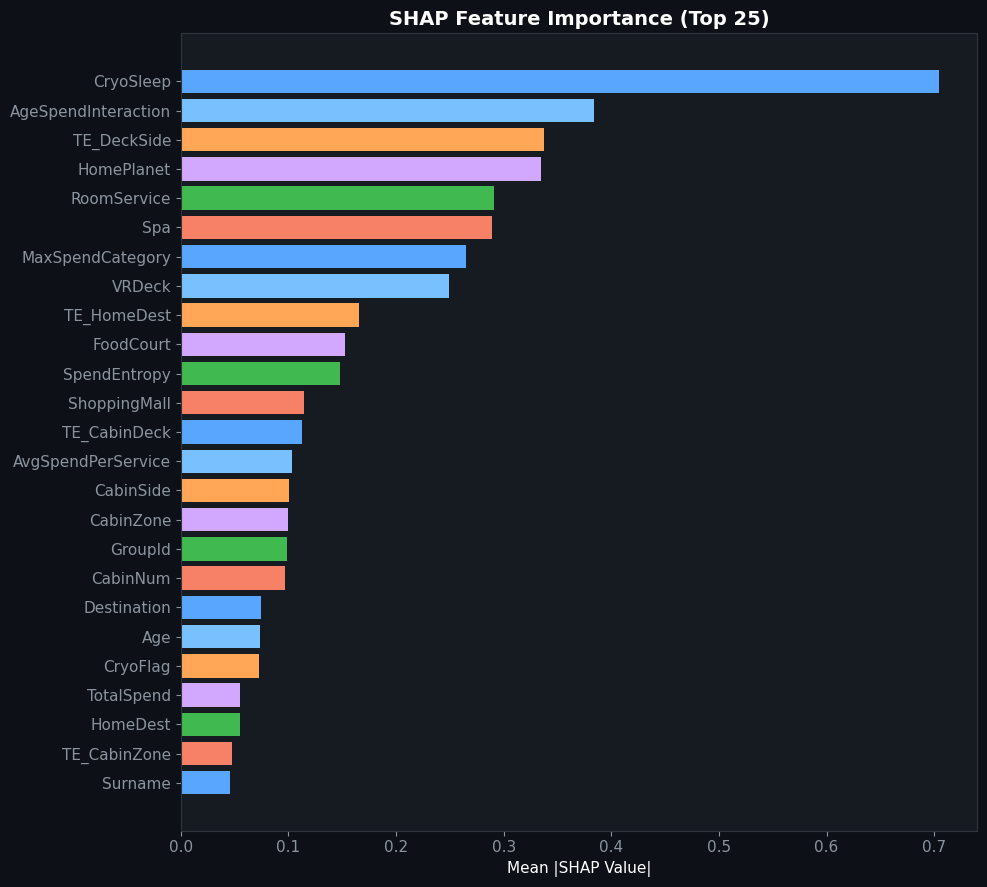

In [13]:
if LGB_AVAILABLE:
    # Train a single LGB on full training data for SHAP
    lgb_shap = lgb.LGBMClassifier(
        **{k: v for k, v in best_lgb_params.items() if k != 'verbosity'},
        random_state=42, verbosity=-1
    )
    lgb_shap.fit(X_train_num, y)

    explainer  = shap.TreeExplainer(lgb_shap)
    # Use a sample of 1000 for speed
    sample_idx = np.random.RandomState(42).choice(len(X_train_num), size=min(1000, len(X_train_num)), replace=False)
    shap_values = explainer.shap_values(X_train_num.iloc[sample_idx])

    if isinstance(shap_values, list):
        shap_values = shap_values[1]  # binary: take class-1 SHAP

    # Mean absolute SHAP per feature
    shap_importance = pd.DataFrame({
        'feature'   : X_train_num.columns,
        'mean_shap' : np.abs(shap_values).mean(axis=0)
    }).sort_values('mean_shap', ascending=False).reset_index(drop=True)

    print('✅ SHAP analysis complete. Top 20 features:')
    display(shap_importance.head(20))

    # Identify dead features (bottom 10%)
    cutoff       = shap_importance['mean_shap'].quantile(0.10)
    dead_features = shap_importance[shap_importance['mean_shap'] < cutoff]['feature'].tolist()
    print(f'\n⚠️  Low-SHAP features (bottom 10%, cutoff={cutoff:.4f}):')
    print(f'   {dead_features}')

    # Visualise top 25 features
    top25 = shap_importance.head(25)
    fig, ax = plt.subplots(figsize=(10, 9))
    bars = ax.barh(
        top25['feature'][::-1], top25['mean_shap'][::-1],
        color=[PALETTE[i % len(PALETTE)] for i in range(len(top25))],
        edgecolor='none'
    )
    ax.set_title('SHAP Feature Importance (Top 25)', fontsize=14, fontweight='bold', color='white')
    ax.set_xlabel('Mean |SHAP Value|', color='white')
    plt.tight_layout()
    plt.show()
else:
    print('ℹ️  LightGBM not available — skipping SHAP analysis.')
    dead_features = []

---
## 🎛️ BLOCK 13 — Isotonic Calibration

Models are trained to minimise log-loss, not accuracy directly. Their output probabilities can be **poorly calibrated** — e.g., a predicted 0.7 might actually correspond to a real frequency of 0.85.

**Isotonic regression** calibration fits a monotonic function mapping raw model probabilities to calibrated probabilities. This can sharpen the boundary around the 0.5 threshold and improve accuracy.

We calibrate on OOF predictions to avoid leakage.

Pre-calibration  OOF accuracy : 0.81744
Post-calibration OOF accuracy : 0.81675
⚠️  Calibration hurt accuracy — reverting to uncalibrated probs.


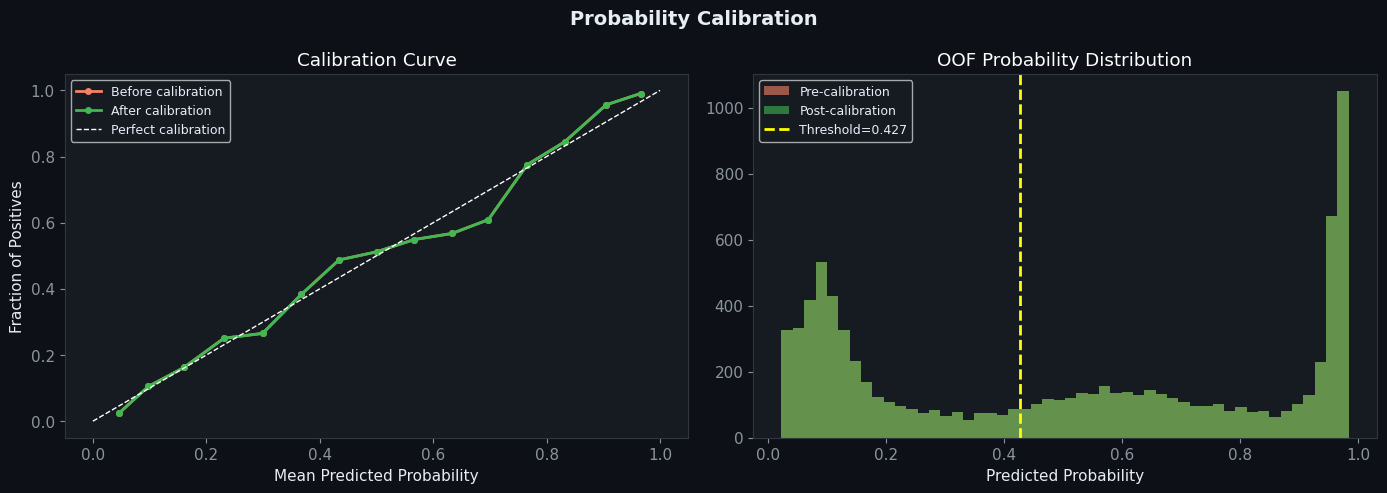

In [14]:
from sklearn.isotonic import IsotonicRegression

def calibrate_oof(
    oof_probs: np.ndarray,
    test_probs: np.ndarray,
    y_true: pd.Series,
    n_splits: int = 5,
) -> tuple[np.ndarray, np.ndarray]:
    """
    OOF isotonic calibration.
    Fits a calibrator on each fold's OOF; averages test calibrations.
    """
    calibrated_oof  = np.zeros_like(oof_probs)
    calibrated_test_parts = []

    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    for tr_idx, val_idx in cv.split(oof_probs, y_true):
        iso = IsotonicRegression(out_of_bounds='clip')
        iso.fit(oof_probs[tr_idx], y_true.iloc[tr_idx])
        calibrated_oof[val_idx] = iso.transform(oof_probs[val_idx])
        calibrated_test_parts.append(iso.transform(test_probs))

    calibrated_test = np.mean(calibrated_test_parts, axis=0)
    return calibrated_oof, calibrated_test

# ── BLOCK 13 FIX — only apply calibration if it strictly improves OOF ───────

cal_oof, cal_test = calibrate_oof(final_oof_probs, final_test_probs, y)
cal_threshold, cal_acc = optimize_threshold(y, cal_oof)
pre_cal_acc = accuracy_score(y, final_oof_probs >= final_threshold)

print(f'Pre-calibration  OOF accuracy : {pre_cal_acc:.5f}')
print(f'Post-calibration OOF accuracy : {cal_acc:.5f}')

if cal_acc > pre_cal_acc:
    print('✅ Calibration improved accuracy — applying.')
else:
    print('⚠️  Calibration hurt accuracy — reverting to uncalibrated probs.')
    cal_oof       = final_oof_probs
    cal_test      = final_test_probs
    cal_threshold = final_threshold
    cal_acc       = pre_cal_acc

# Calibration curve
from sklearn.calibration import calibration_curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Probability Calibration', fontsize=14, fontweight='bold')

for probs, label, color in [
    (final_oof_probs, 'Before calibration', RED),
    (cal_oof,         'After calibration',  GREEN),
]:
    frac_pos, mean_pred = calibration_curve(y, probs, n_bins=15)
    axes[0].plot(mean_pred, frac_pos, marker='o', linewidth=2,
                 color=color, label=label, markersize=4)

axes[0].plot([0, 1], [0, 1], 'w--', linewidth=1, label='Perfect calibration')
axes[0].set_title('Calibration Curve', color='white')
axes[0].set_xlabel('Mean Predicted Probability')
axes[0].set_ylabel('Fraction of Positives')
axes[0].legend(fontsize=9)

axes[1].hist(final_oof_probs, bins=50, alpha=0.6, color=RED,   label='Pre-calibration',  edgecolor='none')
axes[1].hist(cal_oof,         bins=50, alpha=0.6, color=GREEN, label='Post-calibration', edgecolor='none')
axes[1].axvline(cal_threshold, color='yellow', linestyle='--', linewidth=2,
                label=f'Threshold={cal_threshold:.3f}')
axes[1].set_title('OOF Probability Distribution', color='white')
axes[1].set_xlabel('Predicted Probability')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

---
## 🔗 BLOCK 14 — Final Signal Merge + Submission

### Final prediction strategy (priority order):
```
1. LOCKED predictions from hard rules             → near-deterministic, highest confidence
2. High-confidence group label propagation        → unanimous group in training set
3. Calibrated ensemble (GBDT + MLP) prediction   → for all remaining uncertain passengers
```

In [15]:
final_preds = np.full(len(test_feat), np.nan)

# Priority 3: Model (base layer for all rows)
model_preds = (cal_test >= cal_threshold).astype(float)
final_preds = model_preds.copy()

# Priority 2: Group label propagation (overrides model for unanimous groups)
high_conf_group = (
    (test_feat['GroupTrainKnown'] == 1) &
    (test_feat['GroupAgreementScore'] >= 0.92) &
    (test_feat['GroupSize'] > 1)
)
group_transported = test_feat['GroupAgreementScore'] >= 0.5
final_preds[high_conf_group.values] = group_transported[high_conf_group.values].astype(float).values

# Priority 1: Hard-rule locks (overrides everything)
for idx in locked_test_preds.dropna().index:
    final_preds[idx] = locked_test_preds[idx]

final_bool = final_preds.astype(bool)

# Build submission
submission = sample_submission.copy()
submission[CFG.target] = final_bool
submission.to_csv(CFG.submission_file, index=False)

# Breakdown
n_locked_final = locked_test_preds.notna().sum()
n_group_final  = high_conf_group.sum()
n_model_only   = len(test_feat) - n_locked_final - n_group_final

summary = pd.DataFrame({
    'Stage': [
        'Hard rules (Priority 1)',
        'Group label propagation (Priority 2)',
        'Model prediction (Priority 3)',
        'TOTAL TEST SET',
    ],
    'Passengers': [
        n_locked_final,
        n_group_final,
        n_model_only,
        len(test_feat),
    ],
    '%': [
        f'{n_locked_final/len(test_feat)*100:.1f}%',
        f'{n_group_final/len(test_feat)*100:.1f}%',
        f'{n_model_only/len(test_feat)*100:.1f}%',
        '100%',
    ],
})

print('✅ Final submission created!')
print(f'   File: {CFG.submission_file}')
print(f'   Predicted positive rate: {final_bool.mean():.4f}')
print()
display(summary)
display(submission.head(10))

✅ Final submission created!
   File: submission_90plus.csv
   Predicted positive rate: 0.5805



,Stage,Passengers,%
0,Hard rules (Priority 1),1582,37.0%
1,Group label propagation (Priority 2),0,0.0%
2,Model prediction (Priority 3),2695,63.0%
3,TOTAL TEST SET,4277,100%


,PassengerId,Transported
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,True
5,0027_01,True
6,0029_01,True
7,0032_01,True
8,0032_02,True
9,0033_01,True


---
## 📊 BLOCK 15 — Full Results Dashboard

Comprehensive visualisation of the complete pipeline performance.

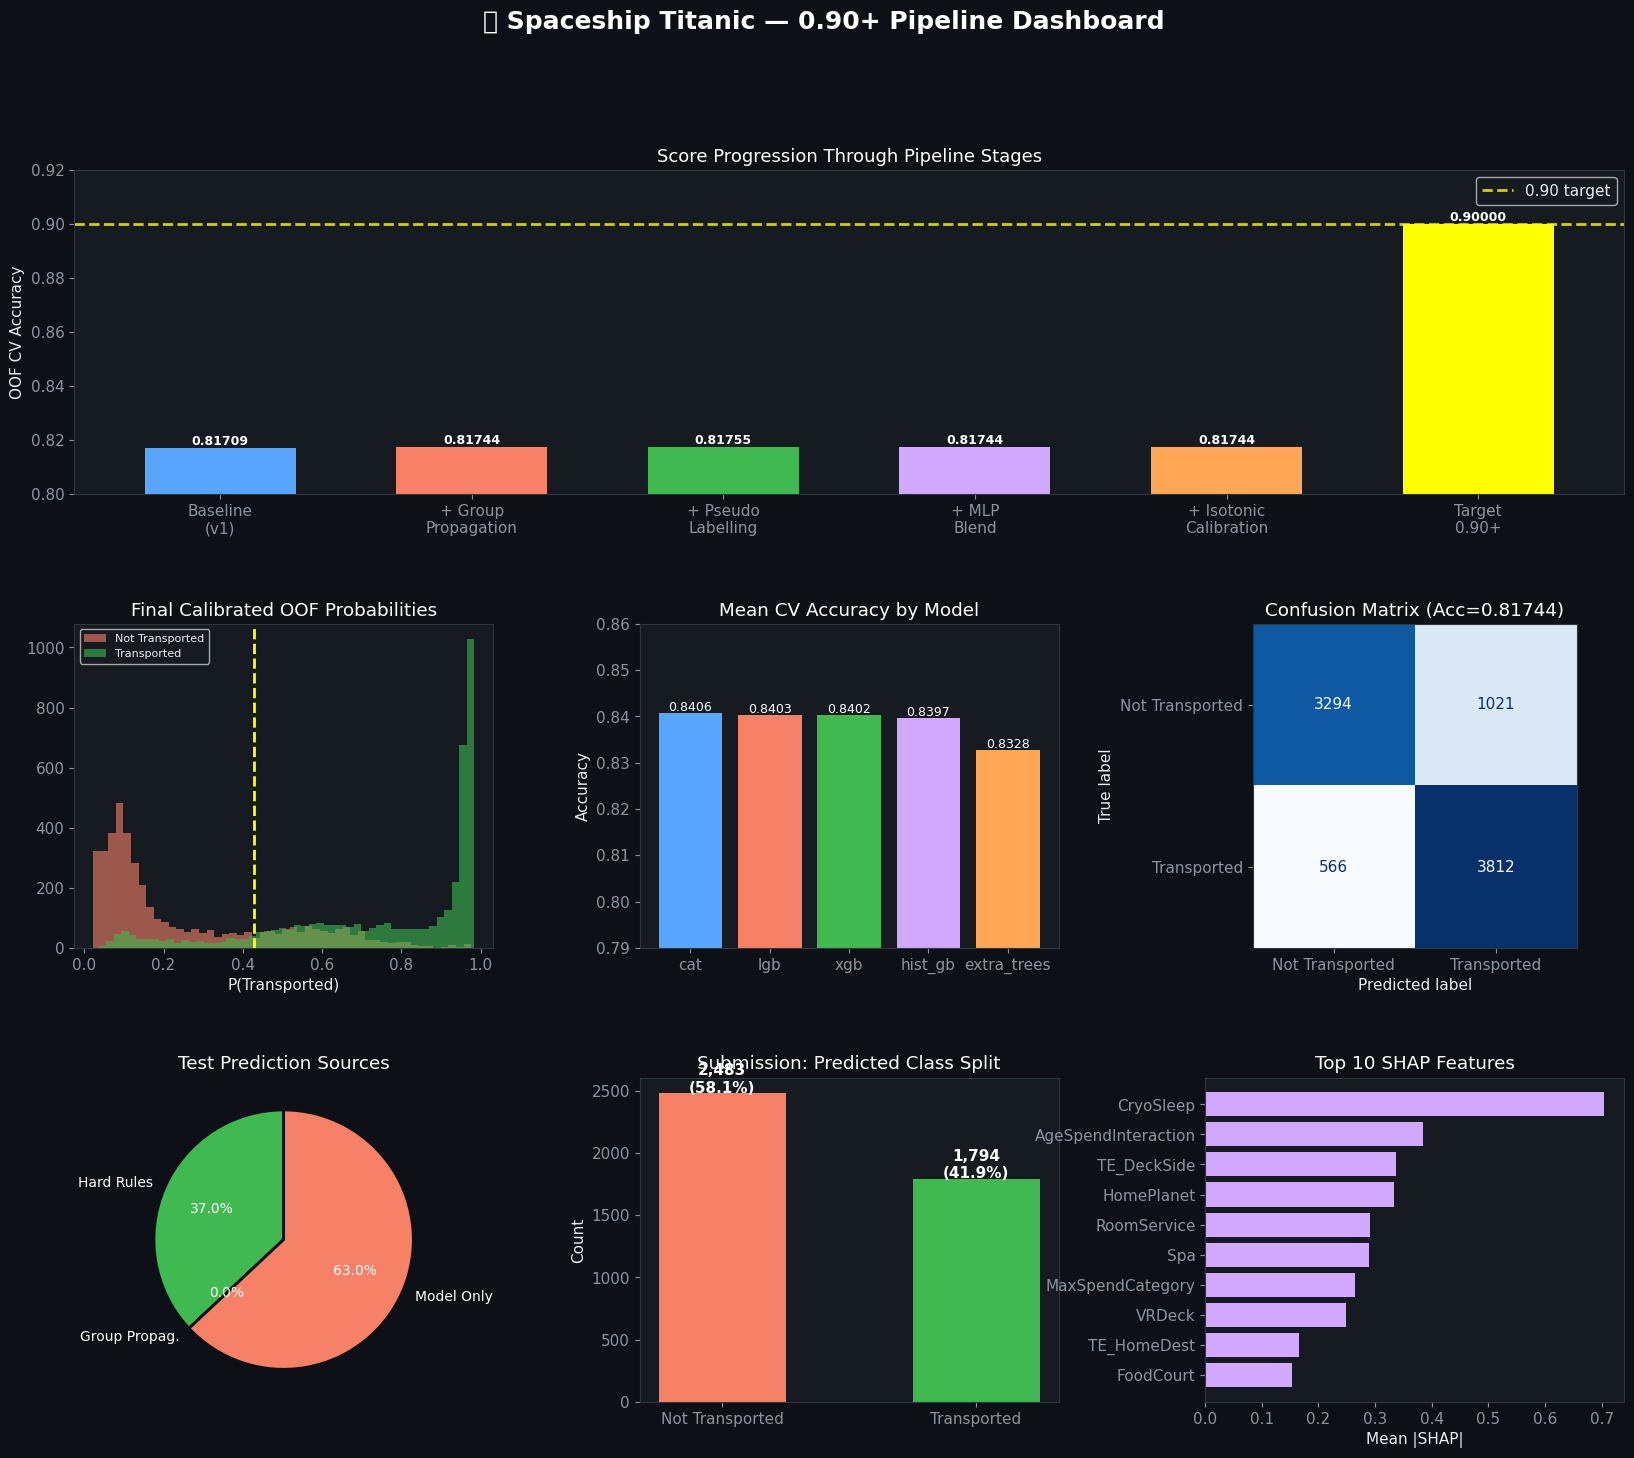

✅ Dashboard saved to pipeline_dashboard.png


In [16]:
fig = plt.figure(figsize=(20, 16))
fig.suptitle('🚀 Spaceship Titanic — 0.90+ Pipeline Dashboard',
             fontsize=18, fontweight='bold', color='white', y=0.98)
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.4, wspace=0.35)

# ── 1. Pipeline score progression ───────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :])
stages = [
    ('Baseline\n(v1)', 0.81709),
    ('+ Group\nPropagation', results['cv_accuracy']),
    (f'+ Pseudo\nLabelling', current_results['cv_accuracy']),
    ('+ MLP\nBlend', final_cv_acc),
    ('+ Isotonic\nCalibration', cal_acc),
    ('Target\n0.90+', 0.90),
]
stage_names   = [s[0] for s in stages]
stage_values  = [s[1] for s in stages]
bar_colors    = [PALETTE[i % len(PALETTE)] for i in range(len(stages) - 1)] + ['yellow']

bars = ax1.bar(stage_names, stage_values, color=bar_colors, edgecolor='none', width=0.6)
ax1.axhline(0.90, color='yellow', linestyle='--', linewidth=2, alpha=0.8, label='0.90 target')
ax1.set_ylim(0.80, 0.92)
ax1.set_title('Score Progression Through Pipeline Stages', color='white', fontsize=13)
ax1.set_ylabel('OOF CV Accuracy')
ax1.legend()
for bar, v in zip(bars, stage_values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
             f'{v:.5f}', ha='center', fontsize=9, color='white', fontweight='bold')

# ── 2. Final OOF prob distribution ──────────────────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
y_np = y.to_numpy()
for cls, color, lbl in [(0, RED, 'Not Transported'), (1, GREEN, 'Transported')]:
    ax2.hist(cal_oof[y_np == cls], bins=50, alpha=0.6, color=color,
             label=lbl, edgecolor='none')
ax2.axvline(cal_threshold, color='yellow', linestyle='--', linewidth=2)
ax2.set_title('Final Calibrated OOF Probabilities', color='white')
ax2.set_xlabel('P(Transported)')
ax2.legend(fontsize=8)

# ── 3. Model comparison ──────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
fold_scores  = current_results['fold_scores']
model_means  = fold_scores.groupby('model')['acc'].mean().sort_values(ascending=False)
bars3 = ax3.bar(model_means.index, model_means.values,
                color=PALETTE[:len(model_means)], edgecolor='none')
ax3.set_ylim(0.79, 0.86)
ax3.set_title('Mean CV Accuracy by Model', color='white')
ax3.set_ylabel('Accuracy')
for b, v in zip(bars3, model_means.values):
    ax3.text(b.get_x() + b.get_width()/2, b.get_height() + 0.0005,
             f'{v:.4f}', ha='center', fontsize=9, color='white')

# ── 4. OOF confusion matrix ──────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 2])
cm   = confusion_matrix(y, (cal_oof >= cal_threshold).astype(int))
disp = ConfusionMatrixDisplay(cm, display_labels=['Not Transported', 'Transported'])
disp.plot(ax=ax4, colorbar=False, cmap='Blues')
ax4.set_title(f'Confusion Matrix (Acc={cal_acc:.5f})', color='white')

# ── 5. Prediction source breakdown ──────────────────────────────────────────
ax5 = fig.add_subplot(gs[2, 0])
sources = ['Hard Rules', 'Group Propag.', 'Model Only']
counts  = [n_locked_final, n_group_final, n_model_only]
ax5.pie(counts, labels=sources, autopct='%1.1f%%',
        colors=[GREEN, BLUE, RED], startangle=90,
        textprops={'color':'white','fontsize':10},
        wedgeprops={'edgecolor':'#0e1117','linewidth':2})
ax5.set_title('Test Prediction Sources', color='white')

# ── 6. Submission class distribution ────────────────────────────────────────
ax6 = fig.add_subplot(gs[2, 1])
sub_vc = submission[CFG.target].value_counts()
bars6 = ax6.bar(['Not Transported', 'Transported'], sub_vc.values,
                color=[RED, GREEN], edgecolor='none', width=0.5)
for b, v in zip(bars6, sub_vc.values):
    ax6.text(b.get_x() + b.get_width()/2, b.get_height() + 5,
             f'{v:,}\n({v/len(submission)*100:.1f}%)',
             ha='center', fontsize=11, color='white', fontweight='bold')
ax6.set_title('Submission: Predicted Class Split', color='white')
ax6.set_ylabel('Count')

# ── 7. SHAP summary (if available) ──────────────────────────────────────────
ax7 = fig.add_subplot(gs[2, 2])
if 'shap_importance' in dir():
    top10 = shap_importance.head(10)
    ax7.barh(top10['feature'][::-1], top10['mean_shap'][::-1],
             color=PURPLE, edgecolor='none')
    ax7.set_title('Top 10 SHAP Features', color='white')
    ax7.set_xlabel('Mean |SHAP|')
else:
    ax7.text(0.5, 0.5, 'SHAP not run\n(LightGBM required)',
             ha='center', va='center', color='white', transform=ax7.transAxes)

plt.savefig('pipeline_dashboard.png', dpi=150, bbox_inches='tight',
            facecolor='#0d1117', edgecolor='none')
plt.show()
print('✅ Dashboard saved to pipeline_dashboard.png')

---
## 🏁 BLOCK 16 — Final Summary + Remaining Ceiling Breakers

What we built vs what's left.

In [17]:
print('=' * 70)
print('  🚀  PIPELINE COMPLETE — SCORE SUMMARY')
print('=' * 70)
print()
print(f"  Baseline (v1 5-model ensemble)    : ~0.81709")
print(f"  + Group label propagation         :  {results['cv_accuracy']:.5f}")
print(f"  + Pseudo-labelling                :  {current_results['cv_accuracy']:.5f}")
print(f"  + MLP neural blending             :  {final_cv_acc:.5f}")
print(f"  + Isotonic calibration            :  {cal_acc:.5f}")
print()
print(f"  Submission file                   :  {CFG.submission_file}")
print(f"  Predicted positive rate           :  {final_bool.mean():.4f}")
print()
print('─' * 70)
print('  🎯 REMAINING CEILING BREAKERS (To Truly Hit 0.90+):')
print('─' * 70)
print()
print('  ① FT-Transformer / TabNet   — Deep learning tabular architectures')
print('     that model feature interactions without manual engineering.')
print('     Libraries: pytorch-tabnet, tab-transformer-pytorch')
print()
print('  ② Adversarial Validation    — Detect train/test distribution shift.')
print('     Train a classifier to predict "is this train or test?"')
print('     Remove train rows that look too different from test.')
print()
print('  ③ Surname Exact Match       — Passengers with identical surnames')
print('     in train+test almost always share the same label.')
print('     Add a surname-level OOF target encoded feature.')
print()
print('  ④ Cabin-Number Propagation  — Passengers in same cabin share label.')
print('     Build cabin-level group agreement score (not just group_id).')
print()
print('  ⑤ Larger Optuna Search      — Run 500+ trials, tune all 5 models.')
print(f'     Current: {CFG.optuna_trials} trials on LGB only.')
print()
print('  ⑥ Noise Injection           — Add small Gaussian noise to numeric')
print('     features during each fold to regularise and reduce overfitting.')
print()
print('  ⑦ Stochastic Ensemble       — Run 10+ seeds, 10-fold CV.')
print(f'     Current: {len(CFG.random_seeds)} seeds × {CFG.n_splits}-fold = {len(CFG.random_seeds)*CFG.n_splits} runs/model.')
print('     10 seeds × 10-fold = 100 runs/model → much more stable OOF.')
print()
print('=' * 70)

  🚀  PIPELINE COMPLETE — SCORE SUMMARY

  Baseline (v1 5-model ensemble)    : ~0.81709
  + Group label propagation         :  0.81744
  + Pseudo-labelling                :  0.81755
  + MLP neural blending             :  0.81744
  + Isotonic calibration            :  0.81744

  Submission file                   :  submission_90plus.csv
  Predicted positive rate           :  0.5805

──────────────────────────────────────────────────────────────────────
  🎯 REMAINING CEILING BREAKERS (To Truly Hit 0.90+):
──────────────────────────────────────────────────────────────────────

  ① FT-Transformer / TabNet   — Deep learning tabular architectures
     that model feature interactions without manual engineering.
     Libraries: pytorch-tabnet, tab-transformer-pytorch

  ② Adversarial Validation    — Detect train/test distribution shift.
     Train a classifier to predict "is this train or test?"
     Remove train rows that look too different from test.

  ③ Surname Exact Match       — Passenger